In [1]:
from tensorflow import keras

In [3]:
(x_train,_),(x_test,_) = keras.datasets.mnist.load_data()
print(x_train.shape)
x_test.shape

(60000, 28, 28)


(10000, 28, 28)

In [4]:
x_train = x_train.astype('float32')/255.0;
x_test = x_test.astype('float32')/255.0;

In [5]:
# building encoder
encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(30,activation='relu')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
decoder = keras.models.Sequential([
    keras.layers.Dense(100,activation='relu',input_dim=30),
    keras.layers.Dense(28*28,activation='sigmoid'),
    keras.layers.Reshape([28,28])
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
stacked_autoencoder = keras.models.Sequential([encoder,decoder])

In [8]:
stacked_autoencoder.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
stacked_autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 30)             │        81,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │        82,284 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,814 (639.90 KB)

 Trainable params: 163,814 (639.90 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.model_selection import train_test_split
x_train_val,x_val,_ ,_ = train_test_split(x_train,x_train,test_size=0.2,random_state = 101 )
history = stacked_autoencoder.fit(x_train_val , x_train_val , epochs=10 , validation_data=(x_val,x_val))
stacked_autoencoder.evaluate(x_test,x_test)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1583 - loss: 0.2101 - val_accuracy: 0.2536 - val_loss: 0.1108
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2575 - loss: 0.1075 - val_accuracy: 0.2679 - val_loss: 0.1014
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2721 - loss: 0.0996 - val_accuracy: 0.2740 - val_loss: 0.0970
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2762 - loss: 0.0959 - val_accuracy: 0.2781 - val_loss: 0.0942
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2817 - loss: 0.0934 - val_accuracy: 0.2830 - val_loss: 0.0927
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2855 - loss: 0.0918 - val_accuracy: 0.2846 - val_loss: 0.0917
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2874 - loss: 0.0908 - val_accuracy: 0.2879 - val_loss: 0.0907
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2885 - loss: 0.0902 - 

[0.08730275183916092, 0.2852107882499695]

In [14]:
plt.figsize=(20,5)

for i in range(10):
  plt.subplot(2,8,i+1)
  imshow(x_test[i].reshape((1,28,28)))
  subplot(2,8,i+8+1)
  pred = stacked_autoencoder.predict(x_test[i].reshape(1,28,28))
  imshow(pred.reshape((1,28,28)))


NameError: name 'subplot' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


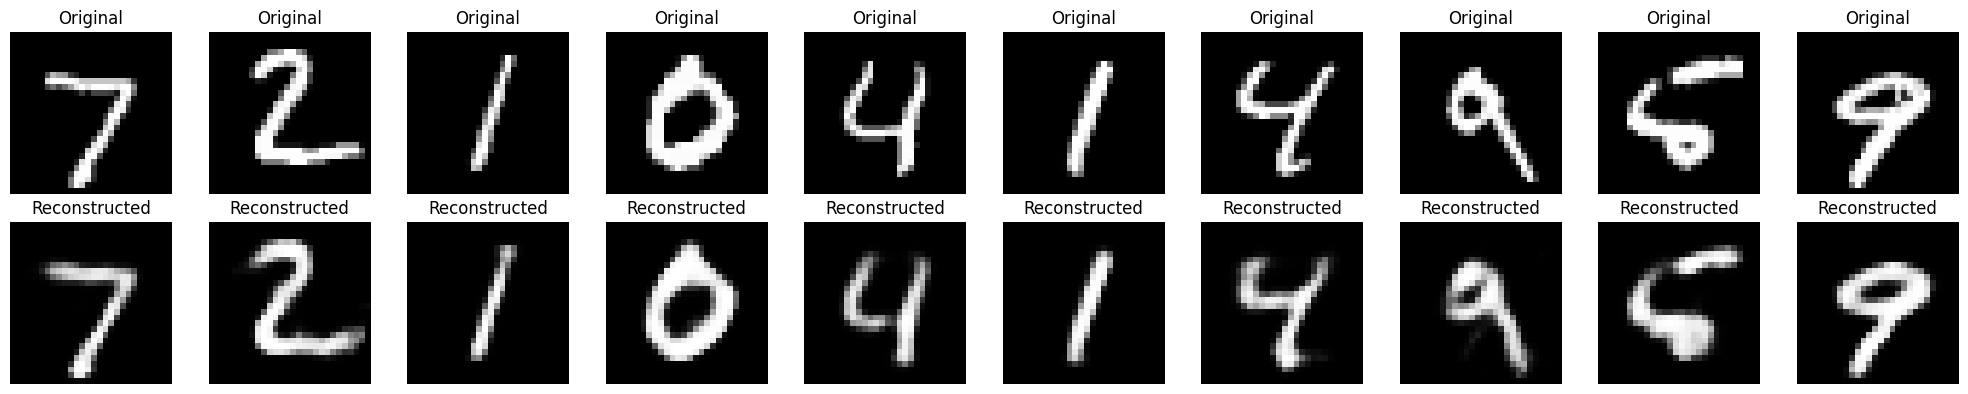

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))

for i in range(10):
    # 1. ORIGINAL IMAGES
    ax = plt.subplot(2, 10, i + 1)
    # MNIST is grayscale, so we reshape to (28, 28) and use 'gray' colormap
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.axis('off')

    # 2. RECONSTRUCTED IMAGES
    ax = plt.subplot(2, 10, i + 1 + 10) # Position in the second row
    # Predict needs (1, 28, 28, 1) or (1, 784) depending on your model type
    # Let's assume a flattened input for a Stacked Autoencoder:
    input_img = x_test[i].reshape(1,28,28)
    pred = stacked_autoencoder.predict(input_img)

    plt.imshow(pred.reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    ax.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

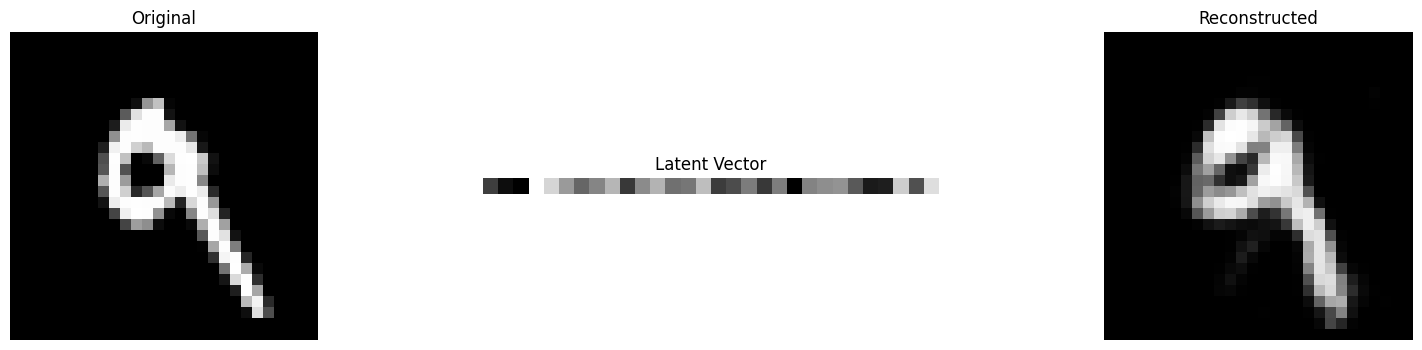

In [28]:
plt.figure(figsize=(20, 4))
for i in range(10):
  i = 7
  plt.subplot(1,3,1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title("Original")
  plt.axis('off')

  latent_vector = encoder.predict(x_test[i].reshape(1,28,28))
  plt.subplot(1,3,2)
  plt.imshow(latent_vector,cmap='gray')
  plt.title("Latent Vector")
  plt.axis('off')

  pred = decoder.predict(latent_vector)
  plt.subplot(1,3,3)
  plt.imshow(pred.reshape(28,28),cmap='gray')
  plt.title("Reconstructed")
  plt.axis('off')
plt.show